In [1]:
import json
import os
import re
import pandas as pd

In [2]:
wk_expert = pd.read_csv('wenkai_subsample_expert_annotation_4_n_each_feature.csv')
ly_expert = pd.read_csv('lynnette_subsample_expert_annotation_4_n_each_feature.csv')

In [25]:
import glob

# 读取baseline和fewshot目录下所有以.jsonl结尾的文件
baseline_files = glob.glob('baseline/*.jsonl')
fewshot_files = glob.glob('fewshot/*.jsonl')
mturk_files = glob.glob('mturk_instruction_with_cot/*.jsonl')

baseline_dfs = {}
fewshot_dfs = {}
mturk_dfs = {}

# 读取baseline下所有jsonl文件为DataFrame
for file in baseline_files:
    with open(file, 'r', encoding='utf-8') as f:
        lines = [json.loads(line) for line in f]
    df = pd.DataFrame(lines)
    basename = os.path.basename(file)
    baseline_dfs[basename] = df

# 读取fewshot下所有jsonl文件为DataFrame
for file in fewshot_files:
    with open(file, 'r', encoding='utf-8') as f:
        lines = [json.loads(line) for line in f]
    df = pd.DataFrame(lines)
    basename = os.path.basename(file).split('.')[0]
    fewshot_dfs[basename] = df
    
for file in mturk_files:
    with open(file, 'r', encoding='utf-8') as f:
        lines = [json.loads(line) for line in f]
    df = pd.DataFrame(lines)
    basename = os.path.basename(file).split('.')[0]
    mturk_dfs[basename] = df

In [8]:
# 遍历计算fewshot_dfs和baseline_dfs每一个dataframe对应的features和总共的agreement

def compute_agreement(df, features):
    """
    计算DataFrame每个feature的agreement（两两一致性比例），以及全部feature的总agreement。
    假设每一行是一个样本，每个feature列是0/1或yes/no。
    """
    # 只保留features列
    feat_df = df[features].copy()
    # 统一转为0/1
    for feat in features:
        feat_df[feat] = feat_df[feat].apply(lambda x: 1 if str(x).strip().lower() in {"yes", "1", "true"} else 0)
    # 计算每个feature的agreement（众数比例）
    agreements = {}
    for feat in features:
        counts = feat_df[feat].value_counts()
        if len(counts) == 0:
            agreements[feat] = None
        else:
            agreements[feat] = counts.max() / counts.sum()
    # 总体agreement：所有feature的所有样本中，众数比例的平均
    all_vals = feat_df.values.flatten()
    all_vals = [v for v in all_vals if pd.notna(v)]
    if len(all_vals) == 0:
        total_agreement = None
    else:
        total_agreement = max((all_vals.count(0), all_vals.count(1))) / len(all_vals)
    return agreements, total_agreement

features = [
    "1gamemove.yes", "2reasoning.yes", "3rapport.yes", "3a_apologies.yes",
    "3a_compliment.yes", "3a_personalthoughts.yes",
    "3a_reassurance.yes", "4shareinformation.yes",
]

print("=== Baseline Agreement ===")
for name, df in baseline_dfs.items():
    agreements, total = compute_agreement(df, features)
    print(f"{name}:")
    for feat in features:
        print(f"  {feat}: {agreements[feat]:.3f}" if agreements[feat] is not None else f"  {feat}: N/A")
    print(f"  Total agreement: {total:.3f}" if total is not None else "  Total agreement: N/A")
    print()

print("=== Fewshot Agreement ===")
for name, df in fewshot_dfs.items():
    agreements, total = compute_agreement(df, features)
    print(f"{name}:")
    for feat in features:
        print(f"  {feat}: {agreements[feat]:.3f}" if agreements[feat] is not None else f"  {feat}: N/A")
    print(f"  Total agreement: {total:.3f}" if total is not None else "  Total agreement: N/A")
    print()

=== Baseline Agreement ===
qwen_8b_judge_baseline.jsonl:
  1gamemove.yes: 0.664
  2reasoning.yes: 0.531
  3rapport.yes: 0.539
  3a_apologies.yes: 0.734
  3a_compliment.yes: 0.906
  3a_personalthoughts.yes: 0.891
  3a_reassurance.yes: 0.922
  4shareinformation.yes: 0.898
  Total agreement: 0.702

llama3_8b_judge_baseline.jsonl:
  1gamemove.yes: 0.562
  2reasoning.yes: 0.648
  3rapport.yes: 0.602
  3a_apologies.yes: 0.500
  3a_compliment.yes: 0.758
  3a_personalthoughts.yes: 0.750
  3a_reassurance.yes: 0.695
  4shareinformation.yes: 0.578
  Total agreement: 0.574

r1_llama_8b_judge_baseline.jsonl:
  1gamemove.yes: 0.797
  2reasoning.yes: 0.742
  3rapport.yes: 0.641
  3a_apologies.yes: 0.586
  3a_compliment.yes: 0.609
  3a_personalthoughts.yes: 0.555
  3a_reassurance.yes: 0.523
  4shareinformation.yes: 0.609
  Total agreement: 0.584

pydantic_llama3_8b_judge_processed_baseline.jsonl:
  1gamemove.yes: 0.602
  2reasoning.yes: 0.641
  3rapport.yes: 0.570
  3a_apologies.yes: 0.547
  3a_compli

In [35]:
# 遍历计算fewshot_dfs和baseline_dfs每一个dataframe对应的features和总共的agreement

def compute_agreement(df, features):
    """
    计算DataFrame每个feature的agreement（两两一致性比例），以及全部feature的总agreement。
    假设每一行是一个样本，每个feature列是0/1或yes/no。
    """
    # 只保留features列
    feat_df = df[features].copy()
    # 统一转为0/1
    for feat in features:
        feat_df[feat] = feat_df[feat].apply(lambda x: 1 if str(x).strip().lower() in {"yes", "1", "true"} else 0)
    # 计算每个feature的agreement（众数比例）
    agreements = {}
    for feat in features:
        counts = feat_df[feat].value_counts()
        if len(counts) == 0:
            agreements[feat] = None
        else:
            agreements[feat] = counts.max() / counts.sum()
    # 总体agreement：所有feature的所有样本中，众数比例的平均
    all_vals = feat_df.values.flatten()
    all_vals = [v for v in all_vals if pd.notna(v)]
    if len(all_vals) == 0:
        total_agreement = None
    else:
        total_agreement = max((all_vals.count(0), all_vals.count(1))) / len(all_vals)
    return agreements, total_agreement

features = [
    "1gamemove.yes", "2reasoning.yes", "3rapport.yes", "3a_apologies.yes",
    "3a_compliment.yes", "3a_personalthoughts.yes",
    "3a_reassurance.yes", "4shareinformation.yes",
]

print("=== Baseline Agreement ===")
for name, df in baseline_dfs.items():
    agreements, total = compute_agreement(df, features)
    print(f"{name}:")
    for feat in features:
        print(f"  {feat}: {agreements[feat]:.3f}" if agreements[feat] is not None else f"  {feat}: N/A")
    print(f"  Total agreement: {total:.3f}" if total is not None else "  Total agreement: N/A")
    print()

print("=== Fewshot Agreement ===")
for name, df in fewshot_dfs.items():
    agreements, total = compute_agreement(df, features)
    print(f"{name}:")
    for feat in features:
        print(f"  {feat}: {agreements[feat]:.3f}" if agreements[feat] is not None else f"  {feat}: N/A")
    print(f"  Total agreement: {total:.3f}" if total is not None else "  Total agreement: N/A")
    print()

=== Baseline Fleiss' Kappa ===
qwen_8b_judge_baseline.jsonl:
  1gamemove.yes: N/A
  2reasoning.yes: N/A
  3rapport.yes: N/A
  3a_apologies.yes: N/A
  3a_compliment.yes: N/A
  3a_personalthoughts.yes: N/A
  3a_reassurance.yes: N/A
  4shareinformation.yes: N/A
  Mean Fleiss' kappa: N/A

llama3_8b_judge_baseline.jsonl:
  1gamemove.yes: N/A
  2reasoning.yes: N/A
  3rapport.yes: N/A
  3a_apologies.yes: N/A
  3a_compliment.yes: N/A
  3a_personalthoughts.yes: N/A
  3a_reassurance.yes: N/A
  4shareinformation.yes: N/A
  Mean Fleiss' kappa: N/A

r1_llama_8b_judge_baseline.jsonl:
  1gamemove.yes: N/A
  2reasoning.yes: N/A
  3rapport.yes: N/A
  3a_apologies.yes: N/A
  3a_compliment.yes: N/A
  3a_personalthoughts.yes: N/A
  3a_reassurance.yes: N/A
  4shareinformation.yes: N/A
  Mean Fleiss' kappa: N/A

pydantic_llama3_8b_judge_processed_baseline.jsonl:
  1gamemove.yes: N/A
  2reasoning.yes: N/A
  3rapport.yes: N/A
  3a_apologies.yes: N/A
  3a_compliment.yes: N/A
  3a_personalthoughts.yes: N/A
  3a

In [9]:
# 遍历计算fewshot_dfs和baseline_dfs每一个dataframe对应的features和总共的agreement

def compute_agreement(df, features):
    """
    计算DataFrame每个feature的agreement（两两一致性比例），以及全部feature的总agreement。
    假设每一行是一个样本，每个feature列是0/1或yes/no。
    """
    # 只保留features列
    feat_df = df[features].copy()
    # 统一转为0/1
    for feat in features:
        feat_df[feat] = feat_df[feat].apply(lambda x: 1 if str(x).strip().lower() in {"yes", "1", "true"} else 0)
    # 计算每个feature的agreement（众数比例）
    agreements = {}
    for feat in features:
        counts = feat_df[feat].value_counts()
        if len(counts) == 0:
            agreements[feat] = None
        else:
            agreements[feat] = counts.max() / counts.sum()
    # 总体agreement：所有feature的所有样本中，众数比例的平均
    all_vals = feat_df.values.flatten()
    all_vals = [v for v in all_vals if pd.notna(v)]
    if len(all_vals) == 0:
        total_agreement = None
    else:
        total_agreement = max((all_vals.count(0), all_vals.count(1))) / len(all_vals)
    return agreements, total_agreement

features = [
    "1gamemove.yes", "2reasoning.yes", "3rapport.yes", "3a_apologies.yes",
    "3a_compliment.yes", "3a_personalthoughts.yes",
    "3a_reassurance.yes", "4shareinformation.yes",
]

print("=== Baseline Agreement ===")
for name, df in baseline_dfs.items():
    agreements, total = compute_agreement(df, features)
    print(f"{name}:")
    for feat in features:
        print(f"  {feat}: {agreements[feat]:.3f}" if agreements[feat] is not None else f"  {feat}: N/A")
    print(f"  Total agreement: {total:.3f}" if total is not None else "  Total agreement: N/A")
    print()

print("=== Fewshot Agreement ===")
for name, df in fewshot_dfs.items():
    agreements, total = compute_agreement(df, features)
    print(f"{name}:")
    for feat in features:
        print(f"  {feat}: {agreements[feat]:.3f}" if agreements[feat] is not None else f"  {feat}: N/A")
    print(f"  Total agreement: {total:.3f}" if total is not None else "  Total agreement: N/A")
    print()

=== Baseline Agreement ===
qwen_8b_judge_baseline.jsonl:
  1gamemove.yes: 0.664
  2reasoning.yes: 0.531
  3rapport.yes: 0.539
  3a_apologies.yes: 0.734
  3a_compliment.yes: 0.906
  3a_personalthoughts.yes: 0.891
  3a_reassurance.yes: 0.922
  4shareinformation.yes: 0.898
  Total agreement: 0.702

llama3_8b_judge_baseline.jsonl:
  1gamemove.yes: 0.562
  2reasoning.yes: 0.648
  3rapport.yes: 0.602
  3a_apologies.yes: 0.500
  3a_compliment.yes: 0.758
  3a_personalthoughts.yes: 0.750
  3a_reassurance.yes: 0.695
  4shareinformation.yes: 0.578
  Total agreement: 0.574

r1_llama_8b_judge_baseline.jsonl:
  1gamemove.yes: 0.797
  2reasoning.yes: 0.742
  3rapport.yes: 0.641
  3a_apologies.yes: 0.586
  3a_compliment.yes: 0.609
  3a_personalthoughts.yes: 0.555
  3a_reassurance.yes: 0.523
  4shareinformation.yes: 0.609
  Total agreement: 0.584

pydantic_llama3_8b_judge_processed_baseline.jsonl:
  1gamemove.yes: 0.602
  2reasoning.yes: 0.641
  3rapport.yes: 0.570
  3a_apologies.yes: 0.547
  3a_compli

In [23]:
fleiss_kappa_df = compute_and_save_all_fleiss_kappa(baseline_dfs, wk_expert, ly_expert)

[WARN] 2 duplicates dropped (keep='last'). Example kept text: 'Happy to aid in the fight against germany and france as well'
[WARN] 2 duplicates dropped (keep='last'). Example kept text: 'Happy to aid in the fight against germany and france as well'
[WARN] 2 duplicates dropped (keep='last'). Example kept text: 'Happy to aid in the fight against germany and france as well'
[WARN] 2 duplicates dropped (keep='last'). Example kept text: 'Happy to aid in the fight against germany and france as well'
[WARN] 2 duplicates dropped (keep='last'). Example kept text: 'Happy to aid in the fight against germany and france as well'
[WARN] 2 duplicates dropped (keep='last'). Example kept text: 'Happy to aid in the fight against germany and france as well'
[WARN] 2 duplicates dropped (keep='last'). Example kept text: 'Happy to aid in the fight against germany and france as well'
[WARN] 2 duplicates dropped (keep='last'). Example kept text: 'Happy to aid in the fight against germany and france as well'


In [24]:
fleiss_kappa_df = compute_and_save_all_fleiss_kappa(fewshot_dfs, wk_expert, ly_expert)

[WARN] 2 duplicates dropped (keep='last'). Example kept text: 'Happy to aid in the fight against germany and france as well'
[WARN] 2 duplicates dropped (keep='last'). Example kept text: 'Happy to aid in the fight against germany and france as well'
[WARN] 2 duplicates dropped (keep='last'). Example kept text: 'Happy to aid in the fight against germany and france as well'
[WARN] 2 duplicates dropped (keep='last'). Example kept text: 'Happy to aid in the fight against germany and france as well'
[WARN] 2 duplicates dropped (keep='last'). Example kept text: 'Happy to aid in the fight against germany and france as well'
[WARN] 2 duplicates dropped (keep='last'). Example kept text: 'Happy to aid in the fight against germany and france as well'
[WARN] 2 duplicates dropped (keep='last'). Example kept text: 'Happy to aid in the fight against germany and france as well'
[WARN] 2 duplicates dropped (keep='last'). Example kept text: 'Happy to aid in the fight against germany and france as well'


In [26]:
fleiss_kappa_df = compute_and_save_all_fleiss_kappa(mturk_dfs, wk_expert, ly_expert)

[WARN] 2 duplicates dropped (keep='last'). Example kept text: 'Happy to aid in the fight against germany and france as well'
[WARN] 2 duplicates dropped (keep='last'). Example kept text: 'Happy to aid in the fight against germany and france as well'
[WARN] 2 duplicates dropped (keep='last'). Example kept text: 'Happy to aid in the fight against germany and france as well'
[WARN] 2 duplicates dropped (keep='last'). Example kept text: 'Happy to aid in the fight against germany and france as well'
[WARN] 2 duplicates dropped (keep='last'). Example kept text: 'Happy to aid in the fight against germany and france as well'
[WARN] 2 duplicates dropped (keep='last'). Example kept text: 'Happy to aid in the fight against germany and france as well'
[WARN] 2 duplicates dropped (keep='last'). Example kept text: 'Happy to aid in the fight against germany and france as well'
[WARN] 2 duplicates dropped (keep='last'). Example kept text: 'Happy to aid in the fight against germany and france as well'


In [32]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from typing import List

def plot_fleiss_kappa_by_family(csv_paths: List[str]) -> None:
    """
    Group models by base family and use a single colormap (不同深浅) for each family.
    """
    # ---------- 1. 读数据 ----------
    df = pd.concat([pd.read_csv(Path(p)) for p in csv_paths], ignore_index=True)

    # ---------- 2. 指定 feature 顺序 ----------
    feature_order = [
        "1gamemove.yes", "2reasoning.yes", "3rapport.yes",
        "3a_apologies.yes", "3a_compliment.yes", "3a_personalthoughts.yes",
        "3a_reassurance.yes", "4shareinformation.yes", "overall",
    ]
    df["feature"] = pd.Categorical(df["feature"], categories=feature_order, ordered=True)
    df = df.sort_values("feature")

    # ---------- 3. 拆分 family / variant ----------
    def split_family_variant(model_name: str):
        parts = model_name.rsplit("_", 1)       # 最后一个 _ 之前都是 family
        family  = parts[0]
        variant = parts[1] if len(parts) > 1 else "base"
        return family, variant

    df[["family", "variant"]] = df["model"].apply(lambda x: pd.Series(split_family_variant(x)))

    # ---------- 4. 拟定 family → colormap ----------
    family_cmap = {
        "llama3_8b"   : plt.cm.Blues,
        "qwen_8b"     : plt.cm.Greens,
        "r1_llama_8b" : plt.cm.Oranges,
    }

    # 给每个 variant 一个深浅值；你可以改成别的逻辑
    variant_level = {"baseline": 0.25, "fewshot": 0.55, "mturk": 0.8}

    # ---------- 5. 透视表 ----------
    pivot = df.pivot(index="feature", columns="model", values="fleiss_kappa")

    # ---------- 6. 生成颜色列表，顺序要与 pivot.columns 对齐 ----------
    colors = []
    for col in pivot.columns:
        fam, var = split_family_variant(col)
        cmap = family_cmap.get(fam, plt.cm.Greys)          # 未列出的 family 用灰色系
        shade = variant_level.get(var, 0.5)                # 未知 variant 中间色
        colors.append(cmap(shade))

    # ---------- 7. 绘图 ----------
    ax = pivot.plot(
        kind="bar",
        figsize=(14, 6),
        color=colors,          # 关键：不同 family 用同一 cmap，不同 variant 用不同 shade
        edgecolor="black",
        width=0.8,
    )

    ax.set_ylabel("Fleiss κ")
    ax.set_xlabel("")
    ax.set_title("Fleiss κ per feature across models")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
    ax.axhline(0, color="gray", linewidth=0.8)
    ax.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()



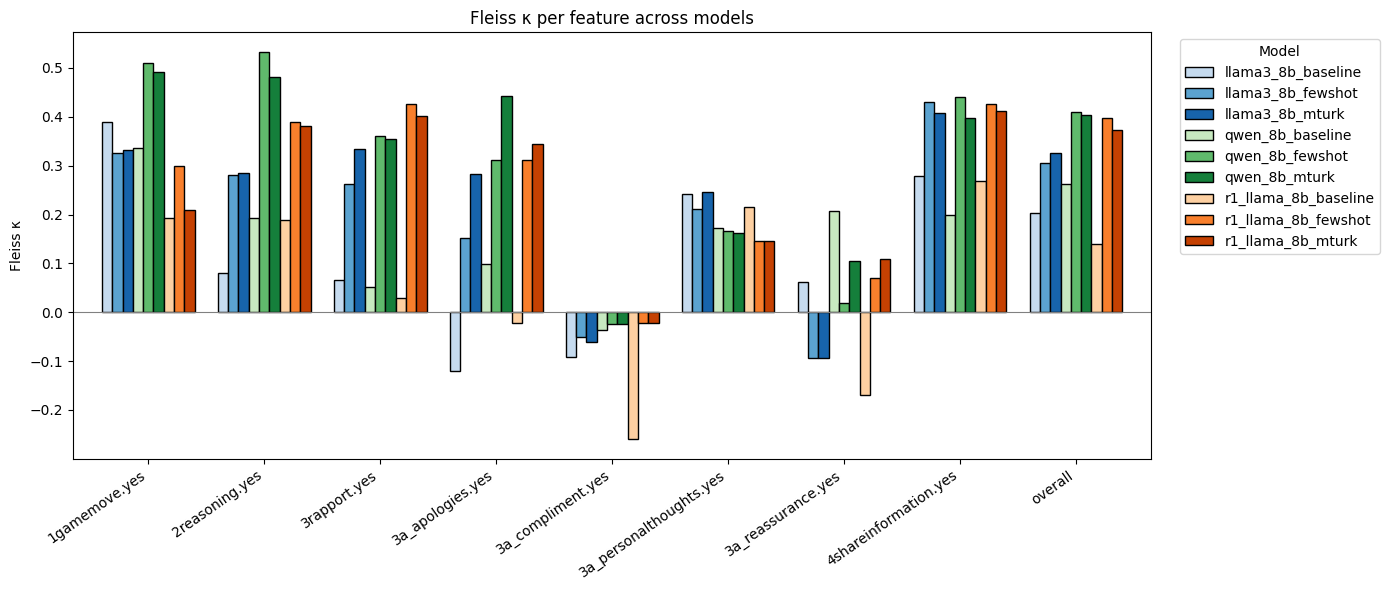

In [33]:
csv_files = [
    "fleiss_kappa/fleiss_kappa_mturk.csv",
    "fleiss_kappa/fleiss_kappa_fewshot.csv",
    "fleiss_kappa/fleiss_kappa_baseline.csv",
]
plot_fleiss_kappa_by_family(csv_files)


In [34]:
# ============================================
# 新增：赢家 vs 败者 的对比曲线
# ============================================
def _yearly_mean_std(df, feature_cols, supply_col, year_col):
    """内部工具：返回按年聚合后的 mean/std DataFrame"""
    return df.groupby(year_col).agg(
        **{f"mean_{supply_col}": (supply_col, "mean")},
        **{f"std_{supply_col}": (supply_col, "std")},
        **{f"mean_roll_{c}": (f"roll_{c}", "mean") for c in feature_cols},
        **{f"std_roll_{c}": (f"roll_{c}", "std") for c in feature_cols},
    ).reset_index()


def plot_mean_curves_compare(
    df_win, df_loss, *,                   # 已 preprocess 的 DF
    feature_cols=FEATURE_COLS,
    supply_col=SUPPLY_COL,
    year_col=YEAR_COL,
    label_win="Winners", label_loss="Losers",
):
    """
    把 winner / loser 的平均 Supply & Feature 曲线画在同一张图上。
    先调用 preprocess，再传进来！
    """
    # --------- 计算均值与方差 ---------
    mean_win  = _yearly_mean_std(df_win,  feature_cols, supply_col, year_col)
    mean_loss = _yearly_mean_std(df_loss, feature_cols, supply_col, year_col)

    # --------- ① Supply 对比 ---------
    plt.figure(figsize=(8, 5))
    plt.plot(mean_win[year_col],  mean_win[f"mean_{supply_col}"],
             marker="o", label=f"{label_win} (mean)",  linewidth=2)
    plt.plot(mean_loss[year_col], mean_loss[f"mean_{supply_col}"],
             marker="s", label=f"{label_loss} (mean)", linewidth=2)
    # 阴影显示 ±1 std
    plt.fill_between(mean_win[year_col],
                     mean_win[f"mean_{supply_col}"]  - mean_win[f"std_{supply_col}"],
                     mean_win[f"mean_{supply_col}"]  + mean_win[f"std_{supply_col}"],
                     alpha=0.15)
    plt.fill_between(mean_loss[year_col],
                     mean_loss[f"mean_{supply_col}"] - mean_loss[f"std_{supply_col}"],
                     mean_loss[f"mean_{supply_col}"] + mean_loss[f"std_{supply_col}"],
                     alpha=0.15)
    plt.xlabel("Year"); plt.ylabel("Supply Centers (mean)")
    plt.title("Mean Supply Centers: Winners vs Losers")
    plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

    # --------- ② 各特征对比 ---------
    n = len(feature_cols); ncols = 2; nrows = int(np.ceil(n/ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows), sharex=True)
    axes = axes.flatten()
    for i, feat in enumerate(feature_cols):
        ax = axes[i]
        w_mean = mean_win [f"mean_roll_{feat}"]; w_std = mean_win [f"std_roll_{feat}"]
        l_mean = mean_loss[f"mean_roll_{feat}"]; l_std = mean_loss[f"std_roll_{feat}"]
        ax.plot(mean_win[year_col],  w_mean, marker="o", label=label_win,  linewidth=2)
        ax.plot(mean_loss[year_col], l_mean, marker="s", label=label_loss, linewidth=2)
        ax.fill_between(mean_win[year_col],  w_mean-w_std, w_mean+w_std, alpha=.10)
        ax.fill_between(mean_loss[year_col], l_mean-l_std, l_mean+l_std, alpha=.10)
        ax.set_title(feat, fontsize=9); ax.grid(alpha=.2)
        if i % ncols == 0: ax.set_ylabel("Mean (3-yr MA)")
        if i // ncols == nrows-1: ax.set_xlabel("Year")
        ax.legend(fontsize=8)
    # 清掉空白子图
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle("Rolling Feature Curves: Winners vs Losers", y=1.02, fontsize=14)
    plt.tight_layout(); plt.show()


# ============================================
# DEMO: 在主函数里调用
# ============================================
if __name__ == "__main__":
    # 假设你已经在 Notebook / 脚本里准备好 df_winner_yearly 和 df_loser_yearly
    if "df_winner_yearly" not in globals() or "df_loser_yearly" not in globals():
        raise ValueError("请先定义 df_winner_yearly 与 df_loser_yearly！")

    # 1) 预处理
    df_win_proc  = preprocess(df_winner_yearly)
    df_loss_proc = preprocess(df_loser_yearly)

    # 2) 赢家-败者平均曲线对比
    plot_mean_curves_compare(df_win_proc, df_loss_proc)

    # 其它分析（如滞后相关、分段占比等）也可以分别对 df_win_proc / df_loss_proc 调用


NameError: name 'FEATURE_COLS' is not defined